In [ ]:
from google.colab import drive
import os


drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive')
os.makedirs('rl_term_project', exist_ok=True)
os.chdir('rl_term_project')
os.makedirs('datasets', exist_ok=True)

# Verify structure
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))
print("\n✓ Project structure ready:")
print("  /content/drive/MyDrive/rl_term_project/")
print("  └── datasets/")

ValueError: mount failed

In [ ]:
import os

os.chdir('/content/drive/MyDrive/rl_term_project/datasets')
print(f"Working directory: {os.getcwd()}")
print(f"Contents: {os.listdir('.')}")

Working directory: /content/drive/MyDrive/rl_term_project/datasets
Contents: []


In [ ]:
!pip install freesound-python librosa soundfile matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00


In [ ]:
import os

base = '/content/drive/MyDrive/rl_term_project/datasets/samples'

categories = ['kick', 'snare', 'hihat', 'clap', 'bass', 'melody', 'pad', 'fx']

for cat in categories:
    os.makedirs(f'{base}/{cat}', exist_ok=True)

print("Created folders:")
for cat in categories:
    print(f"  samples/{cat}/")

Created folders:
  samples/kick/
  samples/snare/
  samples/hihat/
  samples/clap/
  samples/bass/
  samples/melody/
  samples/pad/
  samples/fx/


In [ ]:
!pip install git+https://github.com/MTG/freesound-python.git -q
!pip install librosa soundfile matplotlib numpy -q

import freesound
print(f"freesound version loaded successfully")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
freesound version loaded successfully


In [ ]:
import freesound

CLIENT_ID = "NtQJHTPqq1dS25f2zav6"
CLIENT_SECRET = "DUlTu6Q6fkcXkzmBEualiajL56DIuIq74TuUddA5"

client = freesound.FreesoundClient()

# Step 1: Get authorization URL
auth_url = f"https://freesound.org/apiv2/oauth2/authorize/?client_id={CLIENT_ID}&response_type=code"
print("1. Open this URL in your browser:")
print(f"\n   {auth_url}\n")
print("2. Authorize the app")
print("3. Copy the 'code' parameter from the redirect URL")
print("   (it's the part after ?code= in the URL bar)\n")

auth_code = input("Paste the authorization code here: ")

# Step 2: Exchange code for access token
import requests

response = requests.post("https://freesound.org/apiv2/oauth2/access_token/", data={
    'client_id': CLIENT_ID,
    'client_secret': CLIENT_SECRET,
    'grant_type': 'authorization_code',
    'code': auth_code,
})

token_data = response.json()

if 'access_token' in token_data:
    access_token = token_data['access_token']
    client.set_token(access_token, "oauth")

    # Test connection
    results = client.search(query="kick", fields="id,name", page_size=1)
    print(f"\nOAuth2 connected! Found {results.count} results for 'kick'")
    print("Full WAV downloads enabled.")
else:
    print(f"\nError: {token_data}")

1. Open this URL in your browser:

   https://freesound.org/apiv2/oauth2/authorize/?client_id=NtQJHTPqq1dS25f2zav6&response_type=code

2. Authorize the app
3. Copy the 'code' parameter from the redirect URL
   (it's the part after ?code= in the URL bar)

Paste the authorization code here: F6TUHGFtW3YeGZ9673LTCKJEJYGUsd

OAuth2 connected! Found 16593 results for 'kick'
Full WAV downloads enabled.


In [ ]:
search_config = {
    'kick': {
        'query': 'kick drum',
        'filter': 'tag:kick tag:drum duration:[0 TO 0.8]',
        'target': 15,
        'download': 30,
    },
    'snare': {
        'query': 'snare drum',
        'filter': 'tag:snare tag:drum duration:[0 TO 0.8]',
        'target': 15,
        'download': 30,
    },
    'hihat': {
        'query': 'hi-hat hihat',
        'filter': 'tag:hihat duration:[0 TO 0.6]',
        'target': 12,
        'download': 25,
    },
    'clap': {
        'query': 'clap electronic',
        'filter': 'tag:clap duration:[0 TO 0.6]',
        'target': 10,
        'download': 20,
    },
    'bass': {
        'query': 'bass synth note',
        'filter': 'tag:bass tag:synth duration:[0 TO 1.5]',
        'target': 15,
        'download': 30,
    },
    'melody': {
        'query': 'synth note stab',
        'filter': 'tag:synth tag:note duration:[0 TO 1.5]',
        'target': 15,
        'download': 30,
    },
    'pad': {
        'query': 'pad ambient texture',
        'filter': 'tag:pad duration:[0 TO 3]',
        'target': 10,
        'download': 20,
    },
    'fx': {
        'query': 'fx impact hit',
        'filter': 'tag:fx tag:electronic duration:[0 TO 1.5]',
        'target': 10,
        'download': 20,
    },
}

print(f"Configured {len(search_config)} categories")
for cat, cfg in search_config.items():
    print(f"  {cat}: download {cfg['download']}, keep {cfg['target']}")

Configured 8 categories
  kick: download 30, keep 15
  snare: download 30, keep 15
  hihat: download 25, keep 12
  clap: download 20, keep 10
  bass: download 30, keep 15
  melody: download 30, keep 15
  pad: download 20, keep 10
  fx: download 20, keep 10


In [ ]:
import json
import time
import os

base = '/content/drive/MyDrive/rl_term_project/datasets/samples'

for cat, cfg in search_config.items():
    print(f"\n{'='*50}")
    print(f"Downloading: {cat} (target: {cfg['download']} candidates)")
    print(f"{'='*50}")

    # Rate limit: wait before each category search
    time.sleep(5)

    try:
        results = client.search(
            query=cfg['query'],
            filter=cfg['filter'],
            sort='rating_desc',
            fields='id,name,tags,duration,samplerate,channels,type',
            page_size=cfg['download']
        )
    except Exception as e:
        print(f"  [rate limited on search] waiting 60s...")
        time.sleep(60)
        results = client.search(
            query=cfg['query'],
            filter=cfg['filter'],
            sort='rating_desc',
            fields='id,name,tags,duration,samplerate,channels,type',
            page_size=cfg['download']
        )

    metadata = []
    count = 0

    for sound in results:
        if count >= cfg['download']:
            break
        try:
            filename = f"{sound.id}.wav"
            filepath = f"{base}/{cat}/{filename}"

            if os.path.exists(filepath):
                print(f"  [skip] {sound.name} (already exists)")
                metadata.append({
                    'id': sound.id,
                    'file': filename,
                    'name': sound.name,
                })
                count += 1
                continue

            sound.retrieve(
                directory=f"{base}/{cat}/",
                name=filename
            )

            metadata.append({
                'id': sound.id,
                'file': filename,
                'name': sound.name,
                'tags': list(sound.tags) if hasattr(sound, 'tags') else [],
                'duration': sound.duration if hasattr(sound, 'duration') else 0,
                'samplerate': sound.samplerate if hasattr(sound, 'samplerate') else 44100,
            })

            print(f"  [{count+1}/{cfg['download']}] {sound.name} ({sound.duration:.2f}s)")
            count += 1
            time.sleep(2)  # 2 seconds between each download

        except Exception as e:
            if '429' in str(e):
                print(f"  [rate limited] waiting 60s...")
                time.sleep(60)
                # Retry this one sound
                try:
                    sound.retrieve(directory=f"{base}/{cat}/", name=filename)
                    metadata.append({
                        'id': sound.id, 'file': filename, 'name': sound.name,
                        'tags': list(sound.tags) if hasattr(sound, 'tags') else [],
                        'duration': sound.duration if hasattr(sound, 'duration') else 0,
                    })
                    print(f"  [{count+1}/{cfg['download']}] {sound.name} (retry OK)")
                    count += 1
                    time.sleep(2)
                except:
                    print(f"  [skip after retry] {getattr(sound, 'name', 'unknown')}")
            else:
                print(f"  [error] {getattr(sound, 'name', 'unknown')}: {e}")
            continue

    with open(f"{base}/{cat}/metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"  Done: {count} files downloaded")

print("\nAll downloads complete!")


Downloading: kick (target: 30 candidates)
  [1/30] Synth Kick 3 (0.24s)
  [2/30] gloss stomp messy (0.52s)
  [3/30] KB_Kick_Acoustic_2.wav (0.56s)
  [4/30] BD Magneto.wav (0.27s)
  [5/30] PD-KICK-28.wav (0.53s)
  [6/30] fat lo-fi kick.wav (0.16s)
  [7/30] kick3 (0.40s)
  [8/30] bassdrum2-sfxr.wav (0.11s)
  [9/30] cabinet-3.aiff (0.72s)
  [10/30] Fractanimal_Acoustic_Drum_Kit_Kick_7.wav (0.75s)
  [11/30] Hard Drum Kick (0.40s)
  [12/30] Dub (kick) (0.76s)
  [13/30] Lightly Garbled Stereo Thump.wav (0.55s)
  [14/30] Goa Kick (0.46s)
  [15/30] Analogish_Kick_001.wav (0.35s)
  [16/30] Deep Conversation Snare (0.05s)
  [17/30] KICK G Massive NN (0.79s)
  [18/30] PWLkickpopular4.WAV (0.27s)
  [19/30] SineBassdrum1_ReverbAmpEnv.wav (0.64s)
  [20/30] CLUB KICK 0202.wav (0.28s)
  [21/30] CLUB KICK 0103.wav (0.32s)
  [22/30] LR_K_0006.wav (0.39s)
  [23/30] KICK PACK 0403.wav (0.45s)
  [24/30] bass drumm from uke.flac (0.19s)
  [25/30] Natural Kick Drum (0.12s)
  [26/30] Electronic Kick (0.57s)


In [ ]:
import os

base = '/content/drive/MyDrive/rl_term_project/datasets/samples'

audio_exts = ('.wav', '.mp3', '.ogg', '.flac', '.aiff')

print("Download summary:")
print("-" * 50)
total = 0
for cat in ['kick', 'snare', 'hihat', 'clap', 'bass', 'melody', 'pad', 'fx']:
    path = f"{base}/{cat}"
    audio_files = [f for f in os.listdir(path) if f.lower().endswith(audio_exts)]
    wav_files = [f for f in audio_files if f.lower().endswith('.wav')]
    other_files = [f for f in audio_files if not f.lower().endswith('.wav')]
    total += len(audio_files)

    status = "OK" if len(audio_files) >= search_config[cat]['target'] else "LOW"

    line = f"  {cat:8s}: {len(wav_files):3d} wav"
    if other_files:
        line += f" + {len(other_files)} other"
    line += f"  [{status}]"
    print(line)

print("-" * 50)
print(f"  Total:   {total} files")

Download summary:
--------------------------------------------------
  kick    :  30 wav  [OK]
  snare   :  30 wav  [OK]
  hihat   :  25 wav  [OK]
  clap    :  20 wav  [OK]
  bass    :  30 wav  [OK]
  melody  :   2 wav  [LOW]
  pad     :   1 wav  [LOW]
  fx      :   1 wav  [LOW]
--------------------------------------------------
  Total:   139 files


In [ ]:
import librosa
import soundfile as sf
import numpy as np
import os

base = '/content/drive/MyDrive/rl_term_project/datasets/samples'
output_base = '/content/drive/MyDrive/rl_term_project/datasets/samples_processed'

TARGET_SR = 44100

target_duration = {
    'kick': 0.5, 'snare': 0.5, 'hihat': 0.5, 'clap': 0.5,
    'bass': 1.0, 'melody': 1.0, 'pad': 2.0, 'fx': 1.0,
}

def normalize_audio(y, target_db=-6.0):
    peak = np.max(np.abs(y))
    if peak == 0:
        return y
    target_peak = 10 ** (target_db / 20.0)
    return y * (target_peak / peak)

def pad_or_trim(y, target_len, fade_ms=10):
    if len(y) >= target_len:
        y = y[:target_len]
        fade_samples = int(TARGET_SR * fade_ms / 1000)
        if fade_samples > 0 and fade_samples < len(y):
            fade = np.linspace(1.0, 0.0, fade_samples)
            y[-fade_samples:] *= fade
    else:
        y = np.pad(y, (0, target_len - len(y)))
    return y

audio_exts = ('.wav', '.mp3', '.ogg', '.flac', '.aiff')

for cat in target_duration:
    os.makedirs(f'{output_base}/{cat}', exist_ok=True)
    target_len = int(TARGET_SR * target_duration[cat])

    files = [f for f in os.listdir(f'{base}/{cat}') if f.lower().endswith(audio_exts)]
    processed = 0

    for f in files:
        try:
            y, sr = librosa.load(f'{base}/{cat}/{f}', sr=TARGET_SR, mono=True)

            if np.max(np.abs(y)) < 0.01:
                print(f"  [skip silent] {cat}/{f}")
                continue

            y = normalize_audio(y)
            y = pad_or_trim(y, target_len)

            out_name = os.path.splitext(f)[0] + '.wav'
            sf.write(f'{output_base}/{cat}/{out_name}', y, TARGET_SR)
            processed += 1

        except Exception as e:
            print(f"  [error] {cat}/{f}: {e}")

    print(f"{cat:8s}: {processed} samples → {target_duration[cat]}s @ {TARGET_SR}Hz")

print("\nPreprocessing complete!")

kick    : 30 samples → 0.5s @ 44100Hz
snare   : 30 samples → 0.5s @ 44100Hz
hihat   : 25 samples → 0.5s @ 44100Hz
clap    : 20 samples → 0.5s @ 44100Hz
bass    : 30 samples → 1.0s @ 44100Hz
melody  : 2 samples → 1.0s @ 44100Hz
pad     : 1 samples → 2.0s @ 44100Hz
fx      : 1 samples → 1.0s @ 44100Hz

Preprocessing complete!


In [ ]:
import librosa
import numpy as np
import os

output_base = '/content/drive/MyDrive/rl_term_project/datasets/samples_processed'

print("Final validation:")
print("=" * 60)

all_good = True
for cat in ['kick', 'snare', 'hihat', 'clap', 'bass', 'melody', 'pad', 'fx']:
    path = f'{output_base}/{cat}'
    if not os.path.exists(path):
        print(f"  {cat:8s}: FOLDER MISSING")
        all_good = False
        continue

    wav_files = [f for f in os.listdir(path) if f.endswith('.wav')]

    if len(wav_files) == 0:
        print(f"  {cat:8s}: EMPTY")
        all_good = False
        continue

    durations = []
    sample_rates = []
    peaks = []

    for f in wav_files:
        y, sr = librosa.load(f'{path}/{f}', sr=None, mono=True)
        durations.append(len(y) / sr)
        sample_rates.append(sr)
        peaks.append(np.max(np.abs(y)))

    dur_ok = len(set([round(d, 2) for d in durations])) == 1
    sr_ok = len(set(sample_rates)) == 1
    count_ok = len(wav_files) >= 10
    status = "PASS" if (dur_ok and sr_ok and count_ok) else "CHECK"

    if status != "PASS":
        all_good = False

    print(f"  {cat:8s}: {len(wav_files):3d} files | "
          f"dur={durations[0]:.2f}s | sr={sample_rates[0]} | "
          f"peak=[{min(peaks):.2f}, {max(peaks):.2f}] | [{status}]")

print("=" * 60)
if all_good:
    print("All categories passed!")
else:
    print("Some categories need attention (low count or missing).")
    print("Melody, pad, fx expected to show CHECK — fix before Phase 2.")

Final validation:
  kick    :  30 files | dur=0.50s | sr=44100 | peak=[0.50, 0.50] | [PASS]
  snare   :  30 files | dur=0.50s | sr=44100 | peak=[0.50, 0.50] | [PASS]
  hihat   :  25 files | dur=0.50s | sr=44100 | peak=[0.50, 0.50] | [PASS]
  clap    :  20 files | dur=0.50s | sr=44100 | peak=[0.50, 0.50] | [PASS]
  bass    :  30 files | dur=1.00s | sr=44100 | peak=[0.50, 0.50] | [PASS]
  melody  :   2 files | dur=1.00s | sr=44100 | peak=[0.50, 0.50] | [CHECK]
  pad     :   1 files | dur=2.00s | sr=44100 | peak=[0.50, 0.50] | [CHECK]
  fx      :   1 files | dur=1.00s | sr=44100 | peak=[0.50, 0.50] | [CHECK]
Some categories need attention (low count or missing).
Melody, pad, fx expected to show CHECK — fix before Phase 2.


In [ ]:
!pip install pretty_midi musdb librosa soundfile numpy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 57.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.2/963.2 kB 75.8 MB/s eta 0:00:00


# **Groove-MIDI Dataset loading**

In [ ]:
import os
import urllib.request
import zipfile

base = '/content/drive/MyDrive/rl_term_project/datasets'
groove_dir = f'{base}/groove_midi'
os.makedirs(groove_dir, exist_ok=True)

zip_path = f'{groove_dir}/groove-v1.0.0-midionly.zip'

if not os.path.exists(f'{groove_dir}/groove'):
    print("Downloading Groove MIDI dataset (3MB)...")
    url = 'http://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip'
    urllib.request.urlretrieve(url, zip_path)

    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(groove_dir)

    os.remove(zip_path)
    print("Done!")
else:
    print("Groove MIDI already downloaded.")

# Check what we got
midi_files = []
for root, dirs, files in os.walk(groove_dir):
    for f in files:
        if f.endswith('.mid'):
            midi_files.append(os.path.join(root, f))

print(f"Found {len(midi_files)} MIDI files")

Extracting...
Done!
Found 1150 MIDI files


In [ ]:
import pretty_midi
import numpy as np
import os
import csv

groove_dir = '/content/drive/MyDrive/rl_term_project/datasets/groove_midi/groove'

# Roland TD-11 MIDI note → layer mapping
DRUM_MAP = {
    36: 0,  # Bass Drum → kick
    35: 0,  # Acoustic Bass Drum → kick
    38: 1,  # Snare → snare
    40: 1,  # Electric Snare → snare
    37: 1,  # Side Stick → snare
    42: 2,  # Closed Hi-hat → hihat
    44: 2,  # Pedal Hi-hat → hihat
    46: 2,  # Open Hi-hat → hihat
    49: 3,  # Crash Cymbal → clap/cymbal
    51: 3,  # Ride Cymbal → clap/cymbal
    39: 3,  # Hand Clap → clap
    56: 3,  # Cowbell → clap
}

NUM_LAYERS = 8
NUM_STEPS = 16  # 16th note resolution per bar

# Load metadata to get tempo and time signature info
info_path = f'{groove_dir}/info.csv'
metadata = {}
if os.path.exists(info_path):
    with open(info_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            metadata[row['midi_filename']] = row

# Find all MIDI files
midi_files = []
for root, dirs, files in os.walk(groove_dir):
    for f in files:
        if f.endswith('.mid'):
            midi_files.append(os.path.join(root, f))

print(f"Processing {len(midi_files)} MIDI files...")

all_grids = []
skipped = 0

for midi_path in midi_files:
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)

        # Get tempo
        tempo = pm.estimate_tempo()
        if tempo <= 0:
            tempo = 120.0

        # Duration of one 16th note in seconds
        sixteenth = 60.0 / tempo / 4.0

        # Get total duration
        total_duration = pm.get_end_time()

        # Number of complete bars (assuming 4/4 time)
        bar_duration = sixteenth * 16
        num_bars = int(total_duration / bar_duration)

        if num_bars == 0:
            skipped += 1
            continue

        # Process each bar
        for bar_idx in range(num_bars):
            grid = np.zeros((NUM_LAYERS, NUM_STEPS), dtype=np.int8)
            bar_start = bar_idx * bar_duration

            for instrument in pm.instruments:
                if not instrument.is_drum:
                    continue
                for note in instrument.notes:
                    # Find which step this note falls on
                    note_time = note.start - bar_start
                    if note_time < 0 or note_time >= bar_duration:
                        continue

                    step = int(round(note_time / sixteenth))
                    step = min(step, NUM_STEPS - 1)

                    # Map MIDI note to layer
                    layer = DRUM_MAP.get(note.pitch, None)
                    if layer is not None:
                        grid[layer][step] = 1  # binary: sound present

            # Only keep grids that aren't empty
            if np.sum(grid) > 0:
                all_grids.append(grid)

    except Exception as e:
        skipped += 1
        continue

all_grids = np.array(all_grids)
print(f"Processed: {all_grids.shape[0]} grids from {len(midi_files)} files ({skipped} skipped)")
print(f"Grid shape: {all_grids.shape}")

# Save
save_path = '/content/drive/MyDrive/rl_term_project/datasets/groove_grids.npy'
np.save(save_path, all_grids)
print(f"Saved to {save_path}")

Processing 1150 MIDI files...
Processed: 42133 grids from 1150 files (1 skipped)
Grid shape: (42133, 8, 16)
Saved to /content/drive/MyDrive/rl_term_project/datasets/groove_grids.npy


Shape: (42133, 8, 16)
Total grids: 42133
Grid size: 8 x 16
Value range: [0, 1]
Layers 4-7 all zeros: True
Density: mean=0.127, min=0.016, max=0.375
Kick on strong beats: 11.4%


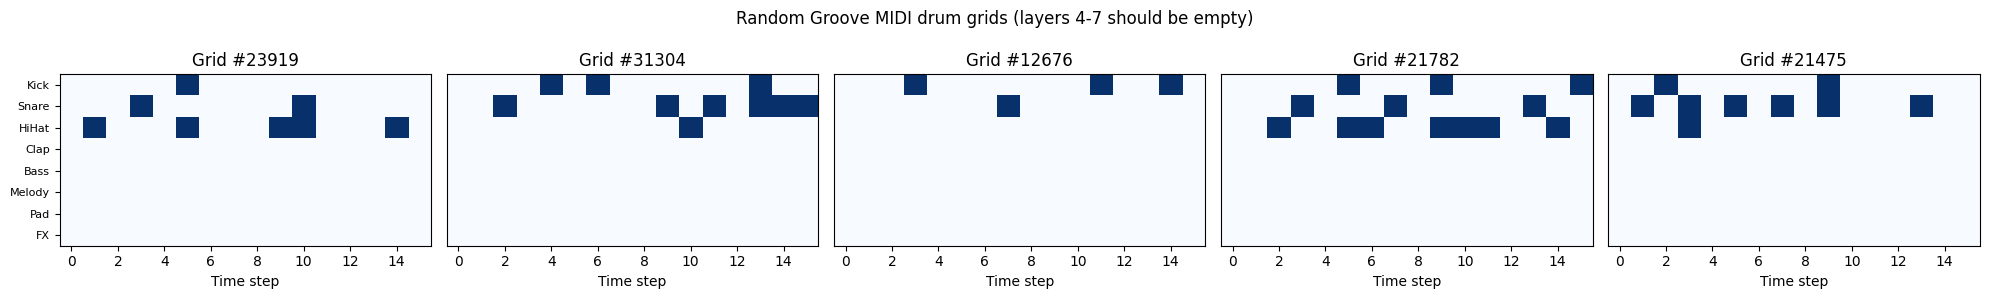

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grids = np.load('/content/drive/MyDrive/rl_term_project/datasets/groove_grids.npy')

print(f"Shape: {grids.shape}")
print(f"Total grids: {grids.shape[0]}")
print(f"Grid size: {grids.shape[1]} x {grids.shape[2]}")
print(f"Value range: [{grids.min()}, {grids.max()}]")
print(f"Layers 4-7 all zeros: {np.all(grids[:, 4:, :] == 0)}")

# Density stats
densities = np.sum(grids[:, :4, :] > 0, axis=(1, 2)) / (4 * 16)
print(f"Density: mean={densities.mean():.3f}, min={densities.min():.3f}, max={densities.max():.3f}")

# Kick on strong beats check
kick_strong = grids[:, 0, [0, 4, 8, 12]]  # steps 0,4,8,12
kick_strong_rate = np.mean(kick_strong > 0)
print(f"Kick on strong beats: {kick_strong_rate:.1%}")

# Visualize 5 random grids
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
layer_names = ['Kick', 'Snare', 'HiHat', 'Clap', 'Bass', 'Melody', 'Pad', 'FX']
indices = np.random.choice(len(grids), 5, replace=False)

for i, idx in enumerate(indices):
    axes[i].imshow(grids[idx], cmap='Blues', aspect='auto', interpolation='nearest')
    axes[i].set_title(f'Grid #{idx}')
    axes[i].set_xlabel('Time step')
    if i == 0:
        axes[i].set_yticks(range(8))
        axes[i].set_yticklabels(layer_names, fontsize=8)
    else:
        axes[i].set_yticks([])

plt.suptitle('Random Groove MIDI drum grids (layers 4-7 should be empty)')
plt.tight_layout()
plt.show()

# **Download BabySlakh (small version)**

In [ ]:
import os
import subprocess

base = '/content/drive/MyDrive/rl_term_project/datasets'
slakh_dir = f'{base}/babyslakh'
os.makedirs(slakh_dir, exist_ok=True)

if not os.path.exists(f'{slakh_dir}/babyslakh_16k'):
    print("Downloading BabySlakh (~1.4GB)... this will take a few minutes.")
    # Use wget — more reliable for large Zenodo downloads
    !wget -q --show-progress -O "{slakh_dir}/babyslakh_16k.zip" \
        "https://zenodo.org/api/records/4603870/files-archive"

    print("Extracting...")
    !unzip -q "{slakh_dir}/babyslakh_16k.zip" -d "{slakh_dir}"
    os.remove(f'{slakh_dir}/babyslakh_16k.zip')
    print("Done!")
else:
    print("BabySlakh already downloaded.")

# Check structure
for d in sorted(os.listdir(slakh_dir)):
    print(f"  {d}")

/content/drive/MyDr     [     <=>            ] 841.92M  22.8MB/s    in 41s     
Extracting...
Done!
  babyslakh_16k.tar.gz


In [ ]:
import os

slakh_dir = '/content/drive/MyDrive/rl_term_project/datasets/babyslakh'

tar_path = f'{slakh_dir}/babyslakh_16k.tar.gz'
if os.path.exists(tar_path):
    print("Extracting tar.gz... this may take a minute.")
    !tar -xzf "{tar_path}" -C "{slakh_dir}"
    os.remove(tar_path)
    print("Done!")

# Show structure
for item in sorted(os.listdir(slakh_dir)):
    item_path = f'{slakh_dir}/{item}'
    if os.path.isdir(item_path):
        print(f"{item}/")
        for sub in sorted(os.listdir(item_path))[:3]:
            sub_path = f'{item_path}/{sub}'
            if os.path.isdir(sub_path):
                print(f"  {sub}/")
                for f in sorted(os.listdir(sub_path))[:5]:
                    print(f"    {f}")
            else:
                print(f"  {sub}")

Extracting tar.gz... this may take a minute.
Done!
babyslakh_16k/
  Track00001/
    ._metadata.yaml
    MIDI
    all_src.mid
    metadata.yaml
    mix.wav
  Track00002/
    MIDI
    all_src.mid
    metadata.yaml
    mix.wav
    stems
  Track00003/
    MIDI
    all_src.mid
    metadata.yaml
    mix.wav
    stems


In [ ]:
import pretty_midi
import numpy as np
import yaml
import os

slakh_dir = '/content/drive/MyDrive/rl_term_project/datasets/babyslakh/babyslakh_16k'

# General MIDI program number → layer mapping
def program_to_layer(program_num, is_drum):
    if is_drum:
        return None
    if 32 <= program_num <= 39:   return 4  # Bass
    if 0 <= program_num <= 7:     return 5  # Piano → melody
    if 80 <= program_num <= 87:   return 5  # Synth Lead → melody
    if 24 <= program_num <= 31:   return 5  # Guitar → melody
    if 48 <= program_num <= 55:   return 6  # Strings → pad
    if 88 <= program_num <= 95:   return 6  # Synth Pad → pad
    if 8 <= program_num <= 15:    return 6  # Chromatic Perc → pad
    return 7  # Everything else → fx

DRUM_MAP = {
    36: 0, 35: 0,
    38: 1, 40: 1, 37: 1,
    42: 2, 44: 2, 46: 2,
    49: 3, 51: 3, 39: 3, 56: 3,
}

NUM_LAYERS = 8
NUM_STEPS = 16

tracks = sorted([d for d in os.listdir(slakh_dir) if d.startswith('Track')])
all_grids = []
processed_tracks = 0

for track_name in tracks:
    track_path = f'{slakh_dir}/{track_name}'
    midi_dir = f'{track_path}/MIDI'
    metadata_path = f'{track_path}/metadata.yaml'

    if not os.path.exists(midi_dir) or not os.path.exists(metadata_path):
        print(f"  [skip] {track_name}: missing MIDI/ or metadata.yaml")
        continue

    # Load metadata
    with open(metadata_path, 'r') as f:
        meta = yaml.safe_load(f)

    # Get list of MIDI stems
    midi_files = [f for f in os.listdir(midi_dir) if f.endswith('.mid')]
    if len(midi_files) == 0:
        print(f"  [skip] {track_name}: no MIDI files")
        continue

    # Determine tempo from first valid MIDI file
    tempo = 120.0
    for mf in midi_files:
        try:
            pm = pretty_midi.PrettyMIDI(f'{midi_dir}/{mf}')
            t = pm.estimate_tempo()
            if t > 0:
                tempo = t
                break
        except:
            continue

    sixteenth = 60.0 / tempo / 4.0
    bar_duration = sixteenth * NUM_STEPS

    # Find total duration across all stems
    max_duration = 0
    for mf in midi_files:
        try:
            pm = pretty_midi.PrettyMIDI(f'{midi_dir}/{mf}')
            max_duration = max(max_duration, pm.get_end_time())
        except:
            continue

    num_bars = int(max_duration / bar_duration)
    if num_bars == 0:
        continue

    # Initialize grids for all bars
    bar_grids = [np.zeros((NUM_LAYERS, NUM_STEPS), dtype=np.int8) for _ in range(num_bars)]

    # Process each MIDI stem
    for mf in midi_files:
        stem_name = mf.replace('.mid', '')

        # Get instrument info from metadata
        stem_meta = meta.get('stems', {}).get(stem_name, {})
        is_drum = stem_meta.get('is_drum', False)
        program = stem_meta.get('program_num', 0)

        try:
            pm = pretty_midi.PrettyMIDI(f'{midi_dir}/{mf}')
        except:
            continue

        for instrument in pm.instruments:
            for note in instrument.notes:
                bar_idx = int(note.start / bar_duration)
                if bar_idx >= num_bars:
                    continue

                note_time = note.start - (bar_idx * bar_duration)
                step = int(round(note_time / sixteenth))
                step = min(step, NUM_STEPS - 1)

                if is_drum or instrument.is_drum:
                    layer = DRUM_MAP.get(note.pitch, None)
                else:
                    layer = program_to_layer(program, False)

                if layer is not None:
                    bar_grids[bar_idx][layer][step] = 1

    # Keep non-empty grids
    track_grids = 0
    for grid in bar_grids:
        if np.sum(grid) > 2:
            all_grids.append(grid)
            track_grids += 1

    processed_tracks += 1
    print(f"  {track_name}: {track_grids}/{num_bars} bars kept, tempo={tempo:.0f}")

all_grids = np.array(all_grids)
print(f"\nProcessed: {processed_tracks} tracks → {all_grids.shape[0]} grids")
print(f"Grid shape: {all_grids.shape}")

save_path = '/content/drive/MyDrive/rl_term_project/datasets/slakh_grids.npy'
np.save(save_path, all_grids)
print(f"Saved to {save_path}")

  Track00001: 40/40 bars kept, tempo=41
  Track00002: 179/185 bars kept, tempo=240
  Track00003: 180/182 bars kept, tempo=205
  Track00004: 103/109 bars kept, tempo=115
  Track00005: 172/173 bars kept, tempo=172
  Track00006: 52/55 bars kept, tempo=56
  Track00007: 146/149 bars kept, tempo=148
  Track00008: 144/149 bars kept, tempo=141
  Track00009: 84/87 bars kept, tempo=135
  Track00010: 79/80 bars kept, tempo=109
  Track00011: 48/49 bars kept, tempo=61
  Track00012: 106/106 bars kept, tempo=84
  Track00013: 175/178 bars kept, tempo=197
  Track00014: 79/79 bars kept, tempo=71
  Track00015: 143/143 bars kept, tempo=142
  Track00016: 105/111 bars kept, tempo=135
  Track00017: 156/159 bars kept, tempo=124
  Track00018: 168/225 bars kept, tempo=186
  Track00019: 160/169 bars kept, tempo=179
  Track00020: 131/132 bars kept, tempo=93

Processed: 20 tracks → 2450 grids
Grid shape: (2450, 8, 16)
Saved to /content/drive/MyDrive/rl_term_project/datasets/slakh_grids.npy


Shape: (2450, 8, 16)
Total grids: 2450

Per-layer activity:
  Kick    : 14.2% of cells active
  Snare   : 10.2% of cells active
  HiHat   : 30.6% of cells active
  Clap    : 7.8% of cells active
  Bass    : 19.6% of cells active
  Melody  : 37.7% of cells active
  Pad     : 12.8% of cells active
  FX      : 10.5% of cells active

Grids with tonal content (layers 4-7): 2439/2450 (99.6%)


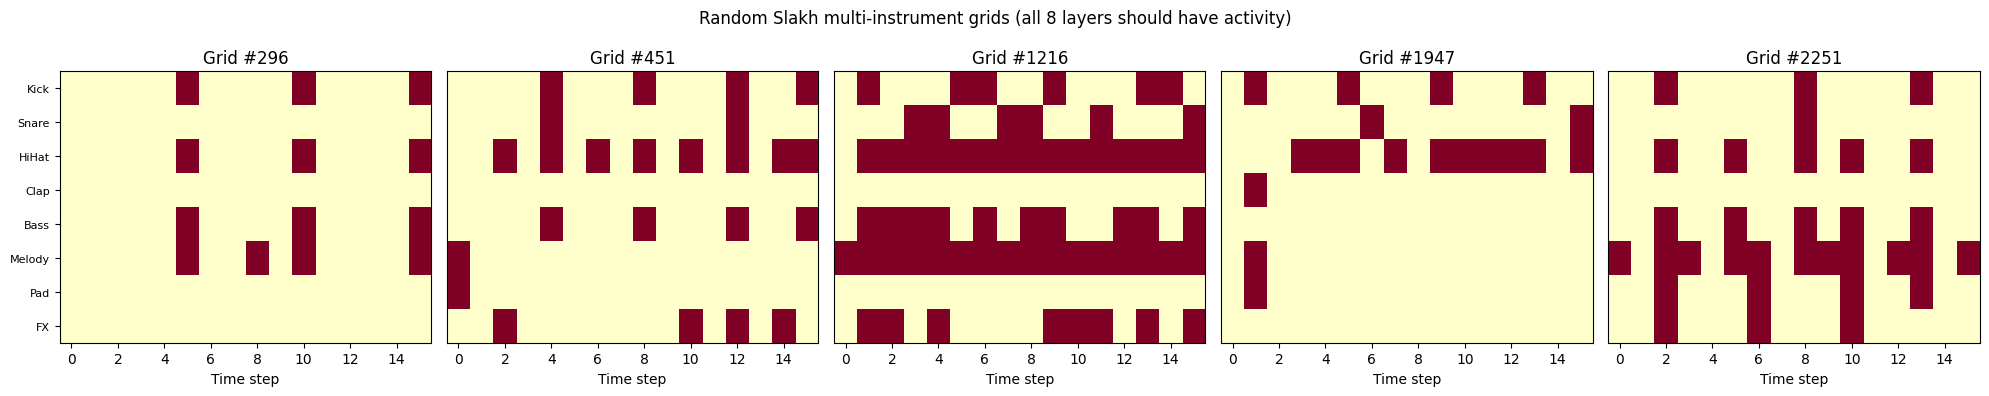

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grids = np.load('/content/drive/MyDrive/rl_term_project/datasets/slakh_grids.npy')
layer_names = ['Kick', 'Snare', 'HiHat', 'Clap', 'Bass', 'Melody', 'Pad', 'FX']

print(f"Shape: {grids.shape}")
print(f"Total grids: {grids.shape[0]}")

# Per-layer activity
print("\nPer-layer activity:")
for i, name in enumerate(layer_names):
    active = np.mean(grids[:, i, :] > 0)
    print(f"  {name:8s}: {active:.1%} of cells active")

# Check layers 4-7 have content
tonal_active = np.any(grids[:, 4:, :] > 0, axis=(1, 2))
print(f"\nGrids with tonal content (layers 4-7): {np.sum(tonal_active)}/{len(grids)} ({np.mean(tonal_active):.1%})")

# Visualize 5 random grids
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
indices = np.random.choice(len(grids), min(5, len(grids)), replace=False)

for i, idx in enumerate(indices):
    axes[i].imshow(grids[idx], cmap='YlOrRd', aspect='auto', interpolation='nearest')
    axes[i].set_title(f'Grid #{idx}')
    axes[i].set_xlabel('Time step')
    if i == 0:
        axes[i].set_yticks(range(8))
        axes[i].set_yticklabels(layer_names, fontsize=8)
    else:
        axes[i].set_yticks([])

plt.suptitle('Random Slakh multi-instrument grids (all 8 layers should have activity)')
plt.tight_layout()
plt.show()

# **Loading and processing MUSDB18 dataset**

In [ ]:
import os

base = '/content/drive/MyDrive/rl_term_project/datasets'
musdb_dir = f'{base}/musdb18'
os.makedirs(musdb_dir, exist_ok=True)

if not os.path.exists(f'{musdb_dir}/train'):
    print("Downloading MUSDB18 (4.7GB)... this will take several minutes.")
    !wget -q --show-progress -O "{musdb_dir}/musdb18.zip" \
        "https://zenodo.org/records/1117372/files/musdb18.zip?download=1"

    print("Extracting...")
    !unzip -q "{musdb_dir}/musdb18.zip" -d "{musdb_dir}"
    os.remove(f'{musdb_dir}/musdb18.zip')
    print("Done!")
else:
    print("MUSDB18 already downloaded.")

# Check structure
for split in ['train', 'test']:
    split_path = f'{musdb_dir}/{split}'
    if os.path.exists(split_path):
        tracks = [f for f in os.listdir(split_path) if f.endswith('.stem.mp4')]
        print(f"{split}: {len(tracks)} tracks")
        if tracks:
            print(f"  Example: {sorted(tracks)[0]}")

/content/drive/MyDr 100%[===================>]   4.36G  23.0MB/s    in 3m 21s  
Extracting...
Done!
train: 100 tracks
  Example: A Classic Education - NightOwl.stem.mp4
test: 50 tracks
  Example: AM Contra - Heart Peripheral.stem.mp4


In [ ]:
!pip install stempeg -q

In [ ]:
import stempeg
import librosa
import numpy as np
import os

musdb_dir = '/content/drive/MyDrive/rl_term_project/datasets/musdb18'

TARGET_SR = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
WINDOW_SEC = 3.0

window_samples = int(TARGET_SR * WINDOW_SEC)
all_specs = []
track_count = 0

# MUSDB18 .stem.mp4 contains 5 streams: 0=mix, 1=drums, 2=bass, 3=other, 4=vocals
# We use streams 1,2,3 (skip mix and vocals)
STEM_INDICES = {1: 'drums', 2: 'bass', 3: 'other'}

for split in ['train', 'test']:
    split_path = f'{musdb_dir}/{split}'
    if not os.path.exists(split_path):
        continue

    stem_files = sorted([f for f in os.listdir(split_path) if f.endswith('.stem.mp4')])

    for stem_file in stem_files:
        filepath = f'{split_path}/{stem_file}'
        try:
            # Load all stems at once
            stems, rate = stempeg.read_stems(filepath)
            # stems shape: (num_stems, num_samples, num_channels)

            for stem_idx, stem_name in STEM_INDICES.items():
                audio = stems[stem_idx]

                # Convert to mono
                if audio.ndim > 1:
                    audio = np.mean(audio, axis=1)

                # Resample
                audio = librosa.resample(audio, orig_sr=rate, target_sr=TARGET_SR)

                # Slice into windows
                num_windows = len(audio) // window_samples
                for w in range(num_windows):
                    chunk = audio[w * window_samples : (w + 1) * window_samples]

                    if np.max(np.abs(chunk)) < 0.01:
                        continue

                    mel = librosa.feature.melspectrogram(
                        y=chunk, sr=TARGET_SR,
                        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
                    )
                    mel_db = librosa.power_to_db(mel, ref=np.max)
                    all_specs.append(mel_db)

            track_count += 1
            if track_count % 10 == 0:
                print(f"  Processed {track_count} tracks ({len(all_specs)} patches)")

        except Exception as e:
            print(f"  [error] {stem_file}: {e}")
            continue

all_specs = np.array(all_specs)
print(f"\nDone: {track_count} tracks → {all_specs.shape[0]} spectrogram patches")
print(f"Patch shape: {all_specs.shape}")
print(f"Size: {all_specs.nbytes / 1e9:.2f} GB")

save_path = '/content/drive/MyDrive/rl_term_project/datasets/musdb_spectrograms.npy'
np.save(save_path, all_specs)
print(f"Saved to {save_path}")

  Processed 10 tracks (2247 patches)
  Processed 20 tracks (4418 patches)
  Processed 30 tracks (6563 patches)
  Processed 40 tracks (8508 patches)
  Processed 50 tracks (10720 patches)
  Processed 60 tracks (12116 patches)
  Processed 70 tracks (12982 patches)
  Processed 80 tracks (15540 patches)
  Processed 90 tracks (17880 patches)
  Processed 100 tracks (20323 patches)
  Processed 110 tracks (22459 patches)
  Processed 120 tracks (24834 patches)
  Processed 130 tracks (26791 patches)
  Processed 140 tracks (29144 patches)
  Processed 150 tracks (31323 patches)

Done: 150 tracks → 31323 spectrogram patches
Patch shape: (31323, 128, 130)
Size: 4.17 GB
Saved to /content/drive/MyDrive/rl_term_project/datasets/musdb_spectrograms.npy


Shape: (31323, 128, 130)
Total patches: 31323
Patch dimensions: 128 mel bands x 130 time frames
Value range: [-80.0, 0.0] dB
No NaN values: True
No all-zero patches: True
File size: 4169.7 MB


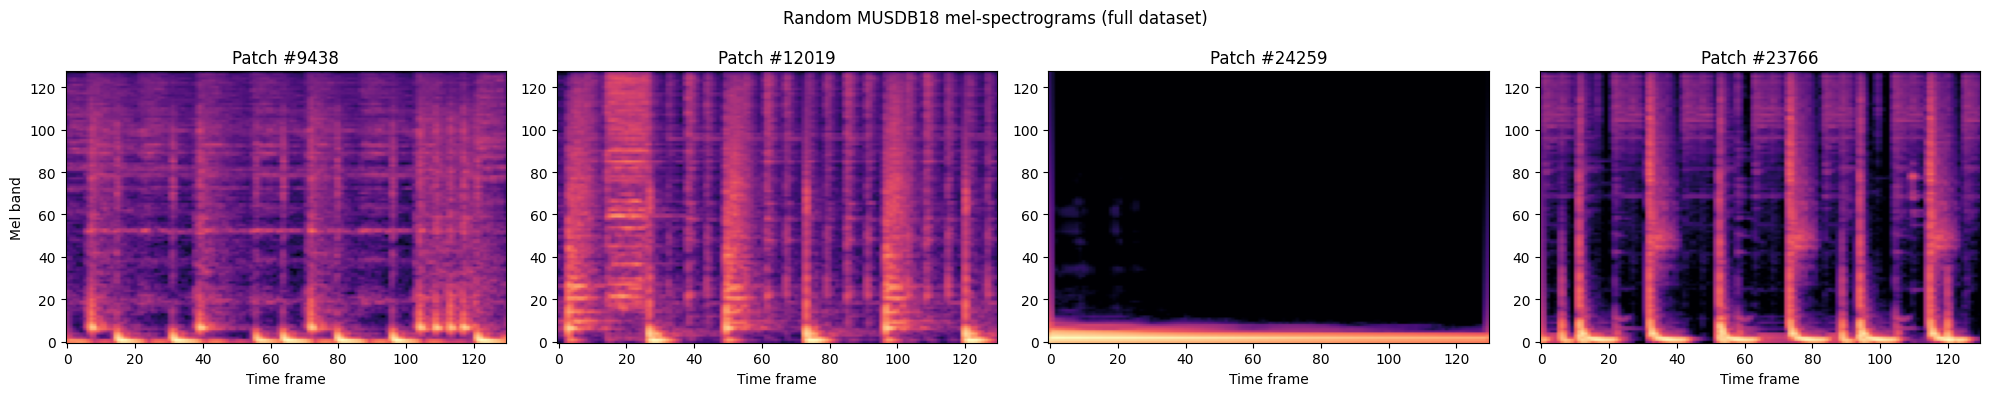

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

specs = np.load('/content/drive/MyDrive/rl_term_project/datasets/musdb_spectrograms.npy')

print(f"Shape: {specs.shape}")
print(f"Total patches: {specs.shape[0]}")
print(f"Patch dimensions: {specs.shape[1]} mel bands x {specs.shape[2]} time frames")
print(f"Value range: [{specs.min():.1f}, {specs.max():.1f}] dB")
print(f"No NaN values: {not np.any(np.isnan(specs))}")
print(f"No all-zero patches: {not np.any(np.all(specs == 0, axis=(1,2)))}")
print(f"File size: {specs.nbytes / 1e6:.1f} MB")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
indices = np.random.choice(len(specs), 4, replace=False)

for i, idx in enumerate(indices):
    axes[i].imshow(specs[idx], aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(f'Patch #{idx}')
    axes[i].set_xlabel('Time frame')
    if i == 0:
        axes[i].set_ylabel('Mel band')

plt.suptitle('Random MUSDB18 mel-spectrograms (full dataset)')
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np

base = '/content/drive/MyDrive/rl_term_project/datasets'

print("=" * 60)
print("DATASET SUMMARY — RL Beat Generation Project")
print("=" * 60)

# 1. Freesound samples
print("\n[1] FREESOUND SAMPLES (Agent's sound library)")
print("-" * 60)
sample_base = f'{base}/samples'
audio_exts = ('.wav', '.mp3', '.ogg', '.flac', '.aiff')
total_samples = 0
for cat in ['kick', 'snare', 'hihat', 'clap', 'bass', 'melody', 'pad', 'fx']:
    path = f'{sample_base}/{cat}'
    if os.path.exists(path):
        n = len([f for f in os.listdir(path) if f.lower().endswith(audio_exts)])
        total_samples += n
        layer = ['kick', 'snare', 'hihat', 'clap', 'bass', 'melody', 'pad', 'fx'].index(cat)
        phase = "Phase 1" if layer < 4 else "Phase 2"
        print(f"  Layer {layer} ({cat:8s}): {n:3d} files  [{phase}]")
    else:
        print(f"  {cat:8s}: MISSING")
print(f"  {'TOTAL':>19s}: {total_samples} files")

# 2. Groove MIDI
print(f"\n[2] GROOVE MIDI (L1 discriminator — drum grids)")
print("-" * 60)
groove_path = f'{base}/groove_grids.npy'
if os.path.exists(groove_path):
    g = np.load(groove_path)
    density = np.mean(g[:, :4, :] > 0)
    print(f"  Grids:      {g.shape[0]}")
    print(f"  Shape:      {g.shape}")
    print(f"  Density:    {density:.1%} (layers 0-3)")
    print(f"  Layers 4-7: {'all zeros (correct)' if np.all(g[:, 4:, :] == 0) else 'WARNING: has content'}")
    print(f"  Used in:    Phase 1 + Phase 2")
else:
    print("  NOT FOUND")

# 3. Slakh
print(f"\n[3] BABYSLAKH (L1 discriminator — multi-instrument grids)")
print("-" * 60)
slakh_path = f'{base}/slakh_grids.npy'
if os.path.exists(slakh_path):
    s = np.load(slakh_path)
    drum_density = np.mean(s[:, :4, :] > 0)
    tonal_density = np.mean(s[:, 4:, :] > 0)
    tonal_grids = np.sum(np.any(s[:, 4:, :] > 0, axis=(1, 2)))
    print(f"  Grids:      {s.shape[0]}")
    print(f"  Shape:      {s.shape}")
    print(f"  Drum density (0-3):  {drum_density:.1%}")
    print(f"  Tonal density (4-7): {tonal_density:.1%}")
    print(f"  Grids w/ tonal:      {tonal_grids}/{len(s)} ({tonal_grids/len(s):.1%})")
    print(f"  Used in:    Phase 2")
    print(f"  Note:       Upgrade to full Slakh2100 for more data")
else:
    print("  NOT FOUND")

# 4. MUSDB18
print(f"\n[4] MUSDB18 (L2 discriminator — audio spectrograms)")
print("-" * 60)
musdb_path = f'{base}/musdb_spectrograms.npy'
if os.path.exists(musdb_path):
    m = np.load(musdb_path, mmap_mode='r')
    print(f"  Patches:    {m.shape[0]}")
    print(f"  Shape:      {m.shape}")
    print(f"  Value range: [{m.min():.1f}, {m.max():.1f}] dB")
    print(f"  File size:  {os.path.getsize(musdb_path) / 1e6:.1f} MB")
    print(f"  Used in:    Phase 3")
else:
    print("  NOT FOUND")

# Overall status
print(f"\n{'=' * 60}")
print("STATUS CHECK")
print("=" * 60)

checks = {
    'Freesound (drums)': total_samples >= 50,
    'Groove MIDI':       os.path.exists(groove_path),
    'Slakh grids':       os.path.exists(slakh_path),
    'MUSDB18 specs':     os.path.exists(musdb_path),
}

all_good = True
for name, passed in checks.items():
    status = "PASS" if passed else "MISSING"
    if not passed:
        all_good = False
    print(f"  {name:25s} [{status}]")

print("=" * 60)
if all_good:
    print("All datasets loaded. Ready to build the environment!")
else:
    print("Some datasets missing — check above before proceeding.")
print("=" * 60)

DATASET SUMMARY — RL Beat Generation Project

[1] FREESOUND SAMPLES (Agent's sound library)
------------------------------------------------------------
  Layer 0 (kick    ):  30 files  [Phase 1]
  Layer 1 (snare   ):  30 files  [Phase 1]
  Layer 2 (hihat   ):  25 files  [Phase 1]
  Layer 3 (clap    ):  20 files  [Phase 1]
  Layer 4 (bass    ):  30 files  [Phase 2]
  Layer 5 (melody  ):   2 files  [Phase 2]
  Layer 6 (pad     ):   1 files  [Phase 2]
  Layer 7 (fx      ):   1 files  [Phase 2]
                TOTAL: 139 files

[2] GROOVE MIDI (L1 discriminator — drum grids)
------------------------------------------------------------
  Grids:      42133
  Shape:      (42133, 8, 16)
  Density:    12.7% (layers 0-3)
  Layers 4-7: all zeros (correct)
  Used in:    Phase 1 + Phase 2

[3] BABYSLAKH (L1 discriminator — multi-instrument grids)
------------------------------------------------------------
  Grids:      2450
  Shape:      (2450, 8, 16)
  Drum density (0-3):  15.7%
  Tonal density 